# E-3DSNN on Talk2Event: pretrained sparse-3D weights -> 2D boxes from events

E-3DSNN (arXiv 2412.07360) is a spiking **sparse 3D** backbone for point clouds. An event
stream is also a sparse 3D volume -- (x, y, t) instead of (x, y, z) -- so its released
detection checkpoint is the closest thing to a pretrained event encoder that the SNN
literature offers. This notebook checks what that transfer is actually worth.

Order of business:

1. **Read the checkpoint before trusting it.** `kitti.pth` does not have the parameter
   layout of the code it ships with.
2. **Feed events in as spike voxels** -- no preprocessing needed, the sensor already
   produced the sparse occupancy grid E-3DSNN's Spike Voxel Coding is designed to build.
3. **Run the pretrained KITTI detection head on events**, i.e. the literal
   "load the weights and predict a box", and look at what comes out.
4. **Replace the head** with a CenterNet-style 2D box head over the pretrained features
   and train it on Talk2Event, with a random-init control so "pretrained" has to earn it.
5. **Predict boxes** on test frames and score them (IoU, recall).

Everything from `repositories/E-3DSNN` is loaded read-only through
`spiketrandvg.utils.forks.load_e3dsnn`; the encoder wrapper lives in
`spiketrandvg.models.e3dsnn_event_encoder`.

In [1]:
from __future__ import annotations

import glob
import warnings
import json
import math
import time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from spiketrandvg.models.e3dsnn_event_encoder import (
    BEV_STRIDE,
    EVENT_H,
    EVENT_W,
    KITTI_RANGE,
    T_FILE,
    Z_SIZE,
    Z_STRIDE,
    E3DSNNEventEncoder,
    events_to_spike_voxels,
    load_pretrained_weights,
    recalibrate_bn,
)
from spiketrandvg.utils import forks

# third-party deprecation noise that would otherwise bury every cell's real output
for msg in ("Using a non-tuple sequence", "torch.meshgrid", "IProgress not found",
            "Importing from timm.models.layers"):
    warnings.filterwarnings("ignore", message=f".*{msg}.*")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA = forks.WS / "dataset" / "talk2event"
CKPT = forks.WS / "spiketrandvg" / "ckpts" / "e3dsnn" / "kitti.pth"
CLASSES = ("pedestrian", "rider", "car", "bus", "truck", "bicycle", "motorcycle", "train")

# Experiment size. The defaults below are the full frame-level splits; drop
# TRAIN_FRAMES/EPOCHS for a quick pass.
TRAIN_FRAMES = None      # None = all 4433 train frames
EVAL_FRAMES = None       # None = all 1134 test frames
EPOCHS = 4
BATCH = 3        # 3 frames x ~0.5M active voxels fits alongside other GPU work
WORKERS = 6
torch.manual_seed(0)

print(f"device {DEVICE} | data {DATA.exists()} | checkpoint {CKPT.exists()}")
print(f"event volume: {T_FILE} time bins x 2 polarities x {EVENT_H}x{EVENT_W}"
      f"  ->  grid z={Z_SIZE} (bin t at z={Z_STRIDE}t), feature stride {BEV_STRIDE}")

device cuda | data True | checkpoint True
event volume: 10 time bins x 2 polarities x 480x640  ->  grid z=41 (bin t at z=4t), feature stride 8


## 1. What is actually inside `kitti.pth`

The only released detection checkpoint is `kitti.pth` on HuggingFace
[`Xuerui123/E-3DSNN`](https://huggingface.co/Xuerui123/E-3DSNN). Before using it as a
spiking encoder it is worth asking whether it *is* one. Two things are checkable
directly from the key names:

* E-3DSNN's blocks are **spike-first** -- `SparseSequential(Multispike(), conv, norm)`
  -- in every commit of the fork. That puts the conv at child index **1** and the norm at
  **2**, and their `conv_input` holds **three** convs.
* OpenPCDet's classic blocks are `(conv, norm, ReLU)`: conv at index **0**, norm at
  **1**, one conv in `conv_input`.

Whichever layout the checkpoint has is the network that was trained.

In [2]:
if not CKPT.exists():
    from huggingface_hub import hf_hub_download
    CKPT.parent.mkdir(parents=True, exist_ok=True)
    hf_hub_download("Xuerui123/E-3DSNN", "kitti.pth", local_dir=str(CKPT.parent))

state = torch.load(CKPT, map_location="cpu", weights_only=False)["model_state"]
groups = defaultdict(int)
for k in state:
    groups[k.split(".")[0]] += 1
print("checkpoint groups:", dict(groups), "\n")

print("first block of the 3D backbone, as stored:")
for k, v in state.items():
    if k.startswith("backbone_3d.conv1.") or k.startswith("backbone_3d.conv_input."):
        print(f"  {k:48s} {tuple(v.shape)}")

print("\nfirst block of the 2D trunk, as stored:")
for k, v in list(state.items()):
    if k.startswith("backbone_2d.blocks.0.") and int(k.split(".")[3]) <= 2:
        print(f"  {k:48s} {tuple(v.shape)}")

checkpoint groups: {'global_step': 1, 'backbone_3d': 72, 'backbone_2d': 84, 'dense_head': 6, 'roi_head': 94} 

first block of the 3D backbone, as stored:
  backbone_3d.conv_input.0.weight                  (3, 3, 3, 4, 16)
  backbone_3d.conv_input.1.weight                  (16,)
  backbone_3d.conv_input.1.bias                    (16,)
  backbone_3d.conv_input.1.running_mean            (16,)
  backbone_3d.conv_input.1.running_var             (16,)
  backbone_3d.conv_input.1.num_batches_tracked     ()
  backbone_3d.conv1.0.0.weight                     (3, 3, 3, 16, 16)
  backbone_3d.conv1.0.1.weight                     (16,)
  backbone_3d.conv1.0.1.bias                       (16,)
  backbone_3d.conv1.0.1.running_mean               (16,)
  backbone_3d.conv1.0.1.running_var                (16,)
  backbone_3d.conv1.0.1.num_batches_tracked        ()

first block of the 2D trunk, as stored:
  backbone_2d.blocks.0.1.weight                    (64, 256, 3, 3)
  backbone_2d.blocks.0.2.weight      

In [3]:
# and what the fork's own spiking block looks like, for comparison
src = (forks.FORKS["e3dsnn"] / "det/pcdet/models/backbones_3d/spconv_backbone_spike.py").read_text()
block = src[src.index("def post_act_block"):]
block = block[block.index("m = spconv.SparseSequential"):]
print("E-3DSNN's own block, from the fork source (spike-first):")
print("    " + block[:block.index("return m")].strip())

E-3DSNN's own block, from the fork source (spike-first):
    m = spconv.SparseSequential(
        Multispike(),
        conv,
        norm_fn(out_channels),
    )


`backbone_3d.conv1.0.0.weight` is a **conv** `(3,3,3,16,16)` and `conv1.0.1.*` is a
**BatchNorm**; `conv_input` has a single conv; `backbone_2d.blocks.0.1.weight` is the
conv right after the `ZeroPad2d`. That is the classic `(conv, norm, act)` layout
throughout -- so **the released checkpoint is the ANN VoxelRCNN-Car model, not the
spike-first network in this repo's code.**

Consequences, and they are not cosmetic:

* Loaded into the classic `VoxelBackBone8x` / `BaseBEVBackbone` the weights match
  exactly (verified below: 72/72 and 84/84 tensors, nothing missing or unexpected).
  Loaded into E-3DSNN's spike-first classes, every index is off by one and `conv_input`
  has the wrong number of convs.
* Making the forward pass *spiking* is therefore a **modification** of these weights, not
  the configuration they were trained in: swapping each ReLU for `Multispike`
  (`floor(clamp(x, 0, 4) + 0.5)`) quantises activations the training never saw. That is
  measured in section 7 rather than assumed to be free.

## 2. Events go in as spike voxels, unmodified

`events_to_spike_voxels` merges the two polarity planes into one active site per
(t, y, x) that fired, and hands spconv `[batch, z, y, x]` coordinates with four features
per site. The axis assignment is forced: the detection stack collapses z into channels,
so grid x/y must be the image plane for a 2D box to come out -- which leaves **time on
the axis the pretrained weights learned as height**.

In [4]:
def frame_index(split):
    """event_path -> sorted list of (x0, y0, x1, y1, class_idx), pooling `bbox` + `others`."""
    frames = defaultdict(set)
    for f in sorted(glob.glob(str(DATA / f"meta_data_v10/{split}/*.json"))):
        for item in json.load(open(f)):
            boxes = frames[item["event_path"]]
            for cls, b in [(item["class"], item["bbox"])] + \
                          [(o["class"], o["bbox"]) for o in item.get("others", [])]:
                boxes.add((b["x"], b["y"], b["x"] + b["w"], b["y"] + b["h"], CLASSES.index(cls)))
    return [(p, sorted(v)) for p, v in sorted(frames.items())]


train_index, test_index = frame_index("train"), frame_index("test")
for name, idx in (("train", train_index), ("test", test_index)):
    n_box = sum(len(b) for _, b in idx)
    print(f"{name}: {len(idx)} event frames, {n_box} boxes ({n_box / len(idx):.2f} per frame)")

path, boxes = train_index[0]
events = torch.from_numpy(np.load(DATA / path)["events"].astype(np.float32))
feats, coords = events_to_spike_voxels(events)
print(f"\n{path}")
print(f"  raw volume       {tuple(events.shape)}, {(events > 0).float().mean():.1%} of cells nonzero")
print(f"  active voxels    {coords.shape[0]:,} = {coords.shape[0] / (T_FILE*EVENT_H*EVENT_W):.1%}"
      f" of the (t,y,x) grid")
print(f"  features/site    {tuple(feats.shape)}  ranges "
      + ", ".join(f"[{feats[:, i].min():.1f}, {feats[:, i].max():.1f}]" for i in range(4)))
print(f"  boxes            {len(boxes)}")

train: 4433 event frames, 10321 boxes (2.33 per frame)
test: 1134 event frames, 3127 boxes (2.76 per frame)

data/train/interlaken_00_c/event/000157.npz
  raw volume       (20, 480, 640), 9.7% of cells nonzero
  active voxels    534,196 = 17.4% of the (t,y,x) grid
  features/site    (534196, 4)  ranges [0.0, 70.4], [-40.0, 40.0], [-3.0, 1.0], [0.1, 1.5]
  boxes            2


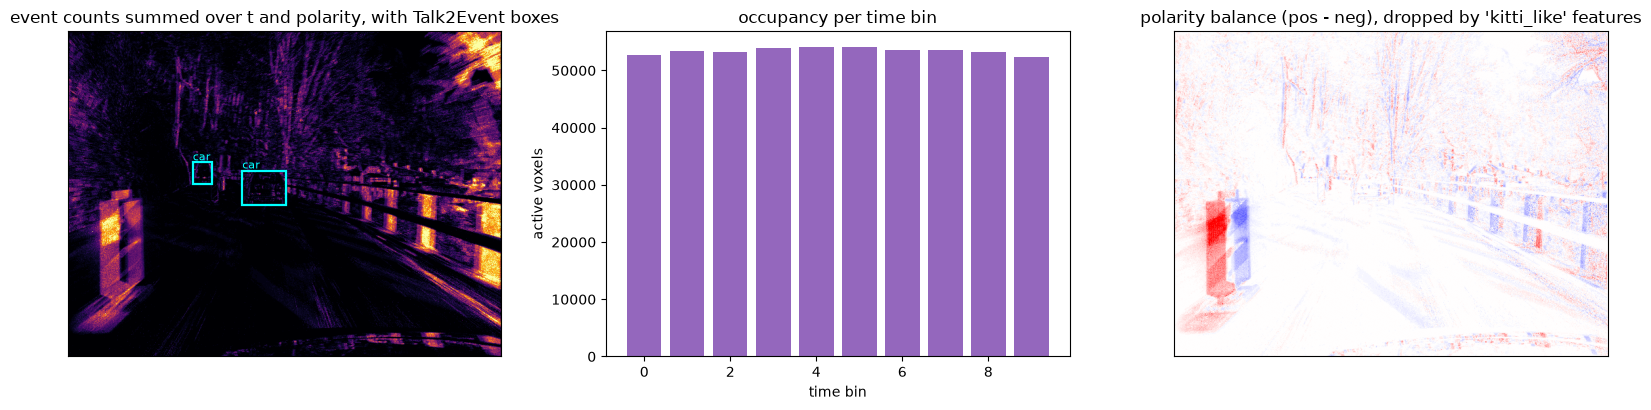

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
frame = events.view(2, T_FILE, EVENT_H, EVENT_W).sum((0, 1))
axes[0].imshow(frame, cmap="inferno", vmax=np.percentile(frame, 99.5))
for x0, y0, x1, y1, c in boxes:
    axes[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="cyan", lw=1.6))
    axes[0].text(x0, y0 - 3, CLASSES[c], color="cyan", fontsize=8)
axes[0].set_title("event counts summed over t and polarity, with Talk2Event boxes")

per_bin = [int((coords[:, 1] == t * Z_STRIDE).sum()) for t in range(T_FILE)]
axes[1].bar(range(T_FILE), per_bin, color="tab:purple")
axes[1].set_xlabel("time bin"); axes[1].set_ylabel("active voxels")
axes[1].set_title("occupancy per time bin")

ev = events.view(2, T_FILE, EVENT_H, EVENT_W)
axes[2].imshow((ev[1].sum(0) - ev[0].sum(0)), cmap="bwr",
               vmin=-np.percentile(frame, 99), vmax=np.percentile(frame, 99))
axes[2].set_title("polarity balance (pos - neg), dropped by 'kitti_like' features")
for a in (axes[0], axes[2]):
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 3. Build the encoder, load the weights, look at the features

Two variants of the same weights: `relu` (the network as trained) and `multispike`
(E-3DSNN's multi-bit spike neuron substituted for every ReLU). The question the feature
statistics answer immediately is whether the spiking substitution leaves anything for a
head to work with.

In [6]:
encoders, reports = {}, {}
for act in ("relu", "multispike"):
    enc = E3DSNNEventEncoder(activation=act).to(DEVICE).eval()
    reports[act] = load_pretrained_weights(enc, CKPT)   # strict: raises on a partial load
    for p in enc.parameters():
        p.requires_grad_(False)
    encoders[act] = enc

for act, rep in reports.items():
    print(f"{act:11s} spike swaps {encoders[act].n_spike_swaps:2d} | "
          + " | ".join(f"{k}: {v}" for k, v in rep.items()))
print(f"\nsparse grid {encoders['relu'].sparse_shape}, output channels {encoders['relu'].out_channels}")

relu        spike swaps  0 | backbone_3d: loaded 72 tensors (12 relaid out for spconv 2.x), 0 missing, 0 unexpected | backbone_2d: loaded 84 tensors (0 relaid out for spconv 2.x), 0 missing, 0 unexpected
multispike  spike swaps 26 | backbone_3d: loaded 72 tensors (12 relaid out for spconv 2.x), 0 missing, 0 unexpected | backbone_2d: loaded 84 tensors (0 relaid out for spconv 2.x), 0 missing, 0 unexpected

sparse grid [41, 480, 640], output channels 256


In [7]:
rows = []
ev_b = events[None].to(DEVICE)
for act, enc in encoders.items():
    torch.cuda.synchronize() if DEVICE == "cuda" else None
    with torch.no_grad():
        for _ in range(2):                     # warm up, then time
            t0 = time.time()
            out = enc(ev_b)
            torch.cuda.synchronize() if DEVICE == "cuda" else None
            dt = time.time() - t0
    bev = out["bev"]
    rows.append((act, tuple(bev.shape), f"{dt*1e3:.0f} ms", f"{bev.mean():+.4f}",
                 f"{bev.std():.4f}", f"{(bev != 0).float().mean():.3f}",
                 f"{(out['x_conv4'].features != 0).float().mean():.3f}"))

hdr = ("activation", "bev shape", "fwd", "mean", "std", "bev nonzero", "conv4 nonzero")
print(f"{hdr[0]:11s} {hdr[1]:>22s} {hdr[2]:>8s} {hdr[3]:>9s} {hdr[4]:>8s} {hdr[5]:>13s} {hdr[6]:>15s}")
for r in rows:
    print(f"{r[0]:11s} {str(r[1]):>22s} {r[2]:>8s} {r[3]:>9s} {r[4]:>8s} {r[5]:>13s} {r[6]:>15s}")
print(f"\npeak GPU memory for one frame: {torch.cuda.max_memory_allocated()/2**30:.2f} GiB"
      if DEVICE == "cuda" else "")

W0821 23:08:25.845000 895827 torch/fx/_symbolic_trace.py:56] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


activation               bev shape      fwd      mean      std   bev nonzero   conv4 nonzero
relu              (1, 256, 60, 80)     8 ms   +0.0351   0.1423         0.190           0.238
multispike        (1, 256, 60, 80)     7 ms   +0.0058   0.0757         0.006           0.141

peak GPU memory for one frame: 1.03 GiB


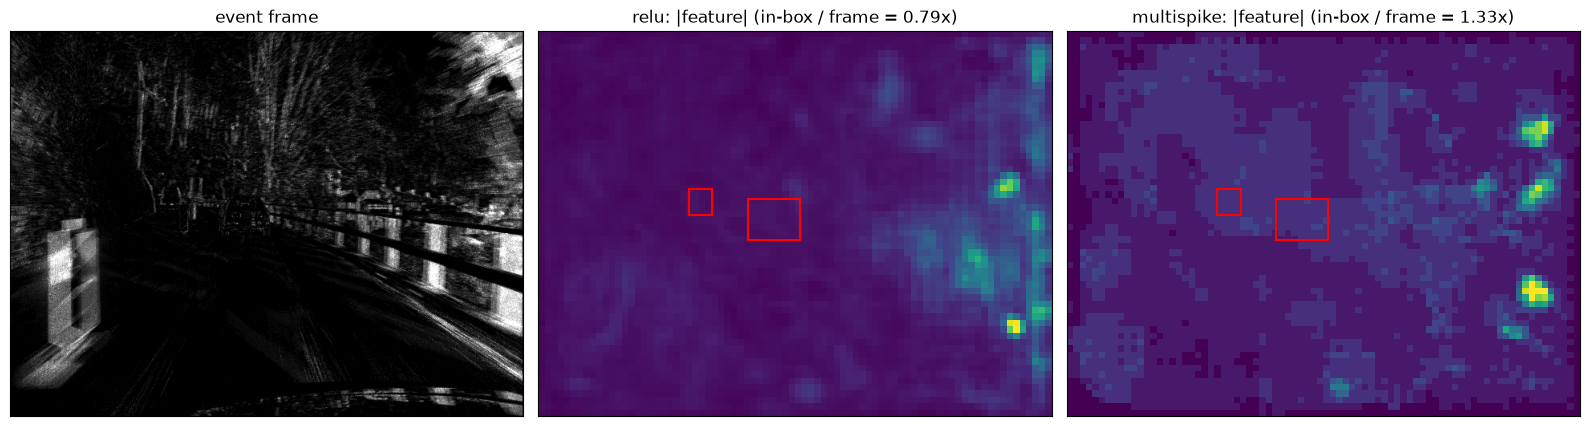

In [8]:
# do the pretrained features respond to objects at all? compare the feature energy
# inside annotated boxes against the frame average, before any training.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].imshow(frame, cmap="gray", vmax=np.percentile(frame, 99.5))
axes[0].set_title("event frame"); axes[0].set_xticks([]); axes[0].set_yticks([])
for ax, (act, enc) in zip(axes[1:], encoders.items()):
    with torch.no_grad():
        bev = enc(ev_b)["bev"][0]
    energy = bev.abs().mean(0).cpu()
    ax.imshow(energy, cmap="viridis")
    for x0, y0, x1, y1, c in boxes:
        ax.add_patch(plt.Rectangle((x0 / BEV_STRIDE, y0 / BEV_STRIDE),
                                   (x1 - x0) / BEV_STRIDE, (y1 - y0) / BEV_STRIDE,
                                   fill=False, ec="red", lw=1.5))
    inside = torch.zeros_like(energy, dtype=torch.bool)
    for x0, y0, x1, y1, c in boxes:
        inside[int(y0 / BEV_STRIDE):int(y1 / BEV_STRIDE) + 1,
               int(x0 / BEV_STRIDE):int(x1 / BEV_STRIDE) + 1] = True
    ratio = energy[inside].mean() / energy.mean()
    ax.set_title(f"{act}: |feature| (in-box / frame = {ratio:.2f}x)")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## 4. The literal answer: what the pretrained KITTI head predicts on events

The checkpoint's `dense_head` is `AnchorHeadSingle` for one class (Car): three 1x1 convs
over the 256-channel map, two anchors per cell (0 and 90 degrees), 7 box parameters each.
Running it needs no compiled pcdet op -- anchors come from the fork's `AnchorGenerator`
and decoding from its `ResidualCoder`, both pure torch.

Its output is a **3D box in KITTI metres**. To see it on the event frame, the metric
prediction is mapped back through the same linear correspondence the input features used
(`KITTI_RANGE` <-> pixel grid).

In [9]:
fork = forks.load_e3dsnn()
ANCHOR_CFG = [{
    "class_name": "Car",
    "anchor_sizes": [[3.9, 1.6, 1.56]],
    "anchor_rotations": [0, 1.57],
    "anchor_bottom_heights": [-1.78],
    "align_center": False,
}]

hm_h, hm_w = EVENT_H // BEV_STRIDE, EVENT_W // BEV_STRIDE
gen = fork.AnchorGenerator(anchor_range=list(KITTI_RANGE), anchor_generator_config=ANCHOR_CFG)
anchors, n_per_loc = gen.generate_anchors([[hm_w, hm_h]])
anchors = anchors[0].to(DEVICE).view(-1, 7)
coder = fork.ResidualCoder(code_size=7)

kitti_head = nn.ModuleDict({
    "conv_cls": nn.Conv2d(256, 2, 1), "conv_box": nn.Conv2d(256, 14, 1),
    "conv_dir_cls": nn.Conv2d(256, 4, 1),
}).to(DEVICE).eval()
head_sd = {k[len("dense_head."):]: v for k, v in state.items() if k.startswith("dense_head.")}
missing = kitti_head.load_state_dict(head_sd, strict=False)
print(f"dense_head tensors loaded: {len(head_sd)}, missing {len(missing.missing_keys)},"
      f" unexpected {len(missing.unexpected_keys)}")
print(f"anchors: {tuple(anchors.shape)} ({n_per_loc[0]} per cell over a {hm_h}x{hm_w} map)")

dense_head tensors loaded: 6, missing 0, unexpected 0
anchors: (9600, 7) (2 per cell over a 60x80 map)


objectness over 9600 anchors: max 0.5847, mean 0.0072, >0.3: 16, >0.1: 49

top-5 anchors -> pixel boxes (xyxy) and score:
     292.5,     5.3,   324.0,    15.0   score 0.5847
     527.0,    35.0,   569.0,    46.6   score 0.5527
     535.9,    35.3,   577.2,    46.9   score 0.5410
     293.2,    12.3,   323.4,    21.9   score 0.5216
     293.8,    18.5,   322.5,    28.0   score 0.5194

GT boxes for this frame:
     184.0,   193.0,   213.0,   225.0   car
     257.0,   205.0,   322.0,   256.0   car


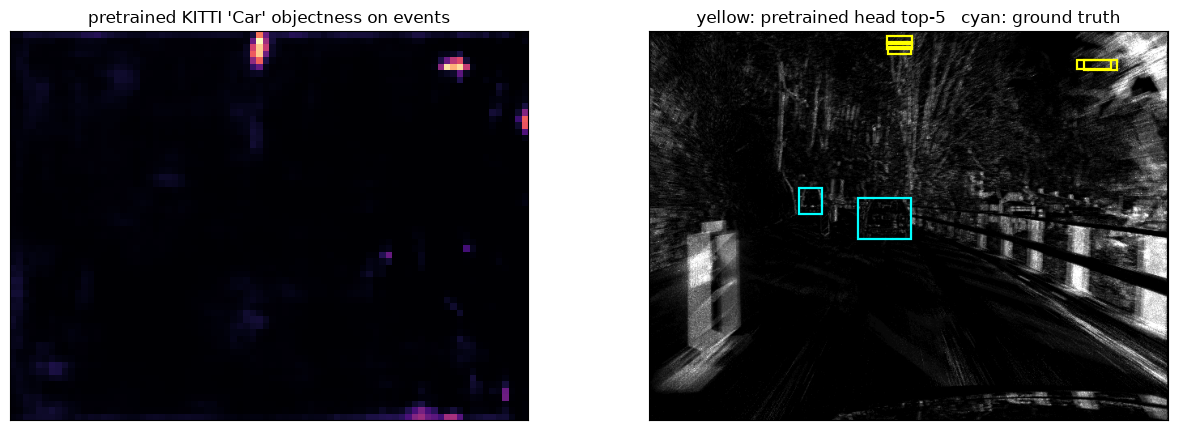

In [10]:
with torch.no_grad():
    bev = encoders["relu"](ev_b)["bev"]
    cls_p = kitti_head["conv_cls"](bev).permute(0, 2, 3, 1).reshape(-1, 1)
    box_p = kitti_head["conv_box"](bev).permute(0, 2, 3, 1).reshape(-1, 7)
    scores = cls_p.sigmoid().squeeze(1)
    boxes3d = coder.decode_torch(box_p, anchors)

print(f"objectness over {scores.numel()} anchors: max {scores.max():.4f}, "
      f"mean {scores.mean():.4f}, >0.3: {(scores > 0.3).sum().item()}, "
      f">0.1: {(scores > 0.1).sum().item()}")

x_min, y_min, _, x_max, y_max, _ = KITTI_RANGE
sx, sy = EVENT_W / (x_max - x_min), EVENT_H / (y_max - y_min)   # px per metre


def metric_to_pixel(b3d):
    """(N,7) KITTI-metric boxes -> (N,4) xyxy pixel boxes under the input's linear map."""
    cx = (b3d[:, 0] - x_min) * sx
    cy = (b3d[:, 1] - y_min) * sy
    w, h = b3d[:, 3] * sx, b3d[:, 4] * sy
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], 1)


top = scores.topk(5).indices
pix = metric_to_pixel(boxes3d[top]).cpu()
print("\ntop-5 anchors -> pixel boxes (xyxy) and score:")
for b, s in zip(pix.tolist(), scores[top].tolist()):
    print("   " + ", ".join(f"{v:7.1f}" for v in b) + f"   score {s:.4f}")
print("\nGT boxes for this frame:")
for x0, y0, x1, y1, c in boxes:
    print(f"   {x0:7.1f}, {y0:7.1f}, {x1:7.1f}, {y1:7.1f}   {CLASSES[c]}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].imshow(scores.view(hm_h, hm_w, -1).max(-1).values.cpu(), cmap="magma")
ax[0].set_title("pretrained KITTI 'Car' objectness on events")
ax[1].imshow(frame, cmap="gray", vmax=np.percentile(frame, 99.5))
for b in pix.tolist():
    ax[1].add_patch(plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, ec="yellow", lw=1.6))
for x0, y0, x1, y1, c in boxes:
    ax[1].add_patch(plt.Rectangle((x0, y0), x1-x0, y1-y0, fill=False, ec="cyan", lw=1.6))
ax[1].set_title("yellow: pretrained head top-5   cyan: ground truth")
for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

This is the honest result of "load the pretrained weights and predict a box": the head
is an anchor regressor tied to KITTI geometry -- one class, a fixed 3.9 x 1.6 x 1.56 m
car prior, offsets in metres relative to anchors laid out over a LiDAR range. Its box
shapes are a property of that prior (3.9 m -> ~35 px wide, 1.6 m -> ~10 px tall at this
mapping), so they cannot match Talk2Event's 64 x 51 px median object whatever the
features say, and its objectness was never trained against event statistics.

The pretrained *features* are the transferable part. The head has to be replaced.

## 5. Frame-level Talk2Event

`Talk2EventDataset` in this package yields one sample per (object, caption) -- the right
unit for grounding, where the caption selects which object is meant. A detector needs the
frame-level view instead: every annotated object in the frame at once, which
`frame_index` above builds by pooling each item's `bbox` with its `others` list.

The event -> voxel conversion runs in the DataLoader workers, so the GPU only ever sees
the sparse tensor.

In [11]:
class Talk2EventFrames(Dataset):
    def __init__(self, index):
        self.index = index

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        path, boxes = self.index[i]
        ev = torch.from_numpy(np.load(DATA / path)["events"].astype(np.float32))
        feats, coords = events_to_spike_voxels(ev)
        return feats, coords, torch.tensor(boxes, dtype=torch.float32), path


def collate(batch):
    feats, coords = [], []
    for i, (f, c, _, _) in enumerate(batch):
        c = c.clone(); c[:, 0] = i
        feats.append(f); coords.append(c)
    return (torch.cat(feats), torch.cat(coords),
            [b[2] for b in batch], [b[3] for b in batch])


train_ds = Talk2EventFrames(train_index[:TRAIN_FRAMES])
test_ds = Talk2EventFrames(test_index[:EVAL_FRAMES])
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=WORKERS,
                      collate_fn=collate, drop_last=True, persistent_workers=True)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=WORKERS,
                     collate_fn=collate, persistent_workers=True)
print(f"train {len(train_ds)} frames / {len(train_dl)} batches | test {len(test_ds)} frames")

train 4433 frames / 1477 batches | test 1134 frames


## 6. A CenterNet-style box head on the pretrained features

Stride 8 over 480x640 gives a 60x80 map. Every Talk2Event box is larger than one cell
(the smallest is wider and taller than 8 px), so a centre-based head is well posed here
-- and the sub-cell offset branch is what keeps the +-4 px quantisation of the stride
from capping IoU.

* **heatmap**: 8 channels (one per Talk2Event class), CenterNet Gaussian targets, focal loss
* **size**: `log w, log h` in cells -- log-scale because the targets span 1 to 80 cells
  and a raw-L1 head spends its capacity on the largest boxes
* **offset**: sub-cell centre correction, L1 at GT centres only

In [12]:
def gaussian_radius(h, w, min_overlap=0.7):
    a1, b1, c1 = 1, h + w, w * h * (1 - min_overlap) / (1 + min_overlap)
    r1 = (b1 - math.sqrt(b1 ** 2 - 4 * a1 * c1)) / 2
    a2, b2, c2 = 4, 2 * (h + w), (1 - min_overlap) * w * h
    r2 = (b2 - math.sqrt(b2 ** 2 - 4 * a2 * c2)) / 2
    a3, b3, c3 = 4 * min_overlap, -2 * min_overlap * (h + w), (min_overlap - 1) * w * h
    r3 = (b3 + math.sqrt(b3 ** 2 - 4 * a3 * c3)) / 2
    return max(0.0, min(r1, r2, r3))


def make_targets(boxes_list, hf, wf, ncls=len(CLASSES), device=DEVICE):
    b = len(boxes_list)
    hm = torch.zeros(b, ncls, hf, wf, device=device)
    wh = torch.zeros(b, 2, hf, wf, device=device)
    off = torch.zeros(b, 2, hf, wf, device=device)
    mask = torch.zeros(b, 1, hf, wf, device=device)
    for i, boxes in enumerate(boxes_list):
        for x0, y0, x1, y1, cls in boxes.tolist():
            cx, cy = (x0 + x1) / 2 / BEV_STRIDE, (y0 + y1) / 2 / BEV_STRIDE
            w, h = (x1 - x0) / BEV_STRIDE, (y1 - y0) / BEV_STRIDE
            ix, iy = int(cx), int(cy)
            if not (0 <= ix < wf and 0 <= iy < hf):
                continue
            r = max(1, int(gaussian_radius(h, w)))
            ys = torch.arange(max(0, iy - r), min(hf, iy + r + 1), device=device)
            xs = torch.arange(max(0, ix - r), min(wf, ix + r + 1), device=device)
            g = torch.exp(-(((xs[None, :] - ix) ** 2 + (ys[:, None] - iy) ** 2)
                            / (2 * (r / 3) ** 2 + 1e-6)))
            win = hm[i, int(cls), ys[0]:ys[-1] + 1, xs[0]:xs[-1] + 1]
            hm[i, int(cls), ys[0]:ys[-1] + 1, xs[0]:xs[-1] + 1] = torch.maximum(win, g)
            wh[i, :, iy, ix] = torch.tensor([math.log(max(w, 1e-3)), math.log(max(h, 1e-3))],
                                            device=device)
            off[i, :, iy, ix] = torch.tensor([cx - ix, cy - iy], device=device)
            mask[i, 0, iy, ix] = 1.0
    return hm, wh, off, mask


class CenterHead(nn.Module):
    def __init__(self, cin=256, cmid=128, ncls=len(CLASSES)):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(cin, cmid, 3, padding=1, bias=False), nn.BatchNorm2d(cmid), nn.ReLU(True),
            nn.Conv2d(cmid, cmid, 3, padding=1, bias=False), nn.BatchNorm2d(cmid), nn.ReLU(True),
        )
        self.hm = nn.Conv2d(cmid, ncls, 1)
        self.wh = nn.Conv2d(cmid, 2, 1)
        self.off = nn.Conv2d(cmid, 2, 1)
        nn.init.constant_(self.hm.bias, -2.19)      # CenterNet prior: p(object) ~ 0.1

    def forward(self, x):
        f = self.stem(x)
        return self.hm(f), self.wh(f), self.off(f)


def focal_loss(pred, gt):
    p = torch.clamp(pred.sigmoid(), 1e-4, 1 - 1e-4)
    pos = (gt == 1).float()
    pos_loss = -((1 - p) ** 2) * torch.log(p) * pos
    neg_loss = -((1 - gt) ** 4) * (p ** 2) * torch.log(1 - p) * (1 - pos)
    return (pos_loss.sum() + neg_loss.sum()) / pos.sum().clamp(min=1)


def decode(hm, wh, off, k=20):
    """heatmap peaks -> (B, k, 6) boxes [x0, y0, x1, y1, score, class] in pixels."""
    scores = hm.sigmoid()
    scores = scores * (scores == F.max_pool2d(scores, 3, 1, 1)).float()   # 3x3 peak NMS
    b, c, hf, wf = scores.shape
    top, idx = scores.view(b, -1).topk(min(k, c * hf * wf), dim=1)
    cls = idx // (hf * wf)
    ys, xs = (idx % (hf * wf)) // wf, (idx % (hf * wf)) % wf
    out = []
    for i in range(b):
        o = off[i].permute(1, 2, 0)[ys[i], xs[i]]
        s = wh[i].permute(1, 2, 0)[ys[i], xs[i]].clamp(-5, 5).exp()
        cx = (xs[i].float() + o[:, 0]) * BEV_STRIDE
        cy = (ys[i].float() + o[:, 1]) * BEV_STRIDE
        w, h = s[:, 0] * BEV_STRIDE, s[:, 1] * BEV_STRIDE
        out.append(torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2,
                                top[i], cls[i].float()], 1))
    return out


def iou_matrix(a, b):
    tl = torch.maximum(a[:, None, :2], b[None, :, :2])
    br = torch.minimum(a[:, None, 2:4], b[None, :, 2:4])
    inter = (br - tl).clamp(min=0).prod(-1)
    area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
    area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)

In [13]:
def sparse_features(enc, feats, coords, bsz):
    """The frozen sparse-3D half: events -> collapsed 256-channel BEV map."""
    import spconv.pytorch as spconv
    b3 = enc.backbone_3d
    x = spconv.SparseConvTensor(feats, coords.int(), b3.sparse_shape, bsz)
    for stage in (b3.conv_input, b3.conv1, b3.conv2, b3.conv3, b3.conv4):
        x = stage(x)
    dense = b3.conv_out(x).dense()
    n, c, d, hh, ww = dense.shape
    return dense.view(n, c * d, hh, ww)


def run_variant(activation, pretrained=True, finetune_2d=False, recal_bn=False,
                reinit_2d=False, epochs=EPOCHS, lr=2e-3, lr_backbone=2e-4):
    enc = E3DSNNEventEncoder(activation=activation).to(DEVICE).eval()
    if pretrained:
        load_pretrained_weights(enc, CKPT)
    if reinit_2d:
        # keep the pretrained sparse-3D half, throw away the pretrained 2D trunk
        enc.backbone_2d.apply(lambda m: m.reset_parameters()
                              if hasattr(m, "reset_parameters") else None)
    for p in enc.parameters():
        p.requires_grad_(False)
    if recal_bn:
        batches = []
        for i, (f, c, bx, _) in enumerate(train_dl):
            batches.append((f, c, len(bx)))
            if i >= 24:
                break
        n_bn = recalibrate_bn(enc, batches, device=DEVICE)
    else:
        n_bn = 0

    head = CenterHead(cin=enc.out_channels).to(DEVICE)
    param_groups = [{"params": head.parameters(), "lr": lr}]
    if finetune_2d:
        for p in enc.backbone_2d.parameters():
            p.requires_grad_(True)
        param_groups.append({"params": enc.backbone_2d.parameters(), "lr": lr_backbone})
    opt = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.OneCycleLR(
        opt, max_lr=[g["lr"] for g in param_groups], total_steps=epochs * len(train_dl))

    history = []
    for ep in range(epochs):
        head.train()
        if finetune_2d:
            enc.backbone_2d.train()
        t0, running = time.time(), 0.0
        for feats, coords, boxes, _ in train_dl:
            # the sparse-3D half is frozen in every run: one no_grad pass per frame
            with torch.no_grad():
                sp = sparse_features(enc, feats.to(DEVICE), coords.to(DEVICE), len(boxes))
            if finetune_2d:
                bev = enc.backbone_2d({"spatial_features": sp})["spatial_features_2d"]
            else:
                with torch.no_grad():
                    bev = enc.backbone_2d({"spatial_features": sp})["spatial_features_2d"]
            hm, wh, off = head(bev)
            t_hm, t_wh, t_off, mask = make_targets(boxes, *bev.shape[-2:])
            m = mask.expand_as(t_wh)
            denom = m.sum().clamp(min=1)
            loss = (focal_loss(hm, t_hm)
                    + F.l1_loss(wh * m, t_wh * m, reduction="sum") / denom
                    + F.l1_loss(off * m, t_off * m, reduction="sum") / denom)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
            running += loss.item()
        history.append(running / len(train_dl))
        print(f"    epoch {ep}: loss {history[-1]:.4f}  ({time.time() - t0:.0f}s)")

    metrics = evaluate(enc, head, finetune_2d)
    metrics.update(history=history, n_bn_recalibrated=n_bn)
    return enc, head, metrics


@torch.no_grad()
def evaluate(enc, head, finetune_2d=False, topk=20):
    enc.eval(); head.eval()
    best_ious, top1_ious, n_gt, cls_hits = [], [], 0, 0
    for feats, coords, boxes, _ in test_dl:
        sp = sparse_features(enc, feats.to(DEVICE), coords.to(DEVICE), len(boxes))
        bev = enc.backbone_2d({"spatial_features": sp})["spatial_features_2d"]
        preds = decode(*head(bev), k=topk)
        for pred, gt in zip(preds, boxes):
            gt = gt.to(DEVICE)
            n_gt += len(gt)
            m = iou_matrix(gt[:, :4], pred[:, :4])
            best, arg = m.max(1)
            best_ious += best.tolist()
            cls_hits += int(((pred[arg, 5] == gt[:, 4]) & (best >= 0.5)).sum())
            top1_ious += iou_matrix(gt[:, :4], pred[:1, :4]).max(1).values.tolist()
    b = np.array(best_ious)
    return {
        "n_gt": n_gt,
        "mean_iou": float(b.mean()),
        "recall@0.25": float((b >= 0.25).mean()),
        "recall@0.5": float((b >= 0.5).mean()),
        "recall@0.75": float((b >= 0.75).mean()),
        "cls_acc@0.5": cls_hits / max(n_gt, 1),
        "top1_iou": float(np.mean(top1_ious)),
    }

## 7. Four runs

| run | what it isolates |
|---|---|
| `relu / frozen` | do the pretrained features already encode event objects? |
| `relu / frozen +BN` | how much of the gap is just stale KITTI BatchNorm statistics |
| `multispike / frozen +BN` | what the spike substitution costs, at its best |
| `relu / finetune 2D +BN` | pretrained sparse-3D features + an adapted 2D trunk |
| `pretrained 3D / fresh 2D` | pretrained sparse-3D features, 2D trunk trained from scratch |
| `random / finetune 2D` | **control** -- same architecture, no pretraining |

The sparse-3D half stays frozen and under `no_grad` throughout, so a run costs one
sparse forward pass per frame per epoch either way.

In [14]:
RUNS = [
    ("relu / frozen",            dict(activation="relu",       pretrained=True)),
    ("relu / frozen +BN",        dict(activation="relu",       pretrained=True, recal_bn=True)),
    ("multispike / frozen +BN",  dict(activation="multispike", pretrained=True, recal_bn=True)),
    ("relu / finetune 2D +BN",   dict(activation="relu",       pretrained=True, recal_bn=True,
                                      finetune_2d=True)),
    ("pretrained 3D / fresh 2D", dict(activation="relu",       pretrained=True, recal_bn=True,
                                      finetune_2d=True, reinit_2d=True)),
    ("random / finetune 2D",     dict(activation="relu",       pretrained=False, finetune_2d=True)),
]

results, trained = {}, {}
for name, kwargs in RUNS:
    print(f"\n=== {name} ===")
    enc, head, metrics = run_variant(**kwargs)
    results[name] = metrics
    trained[name] = (enc, head, kwargs.get("finetune_2d", False))
    print("   " + " | ".join(f"{k} {v:.3f}" for k, v in metrics.items()
                             if isinstance(v, float)))


=== relu / frozen ===


    epoch 0: loss 5.8345  (46s)


    epoch 1: loss 3.5799  (46s)


    epoch 2: loss 3.4232  (46s)


    epoch 3: loss 3.2335  (45s)


...

    epoch 0: loss 5.9443  (47s)


    epoch 1: loss 2.8589  (47s)


    epoch 2: loss 2.4123  (49s)


    epoch 3: loss 1.9888  (48s)


   mean_iou 0.549 | recall@0.25 0.868 | recall@0.5 0.613 | recall@0.75 0.245 | cls_acc@0.5 0.435 | top1_iou 0.191


## 8. Results

run                            mean_iou  recall@0.25   recall@0.5  recall@0.75  cls_acc@0.5     top1_iou
--------------------------------------------------------------------------------------------------------
relu / frozen                     0.274        0.499        0.176        0.021        0.162        0.051
relu / frozen +BN                 0.312        0.579        0.210        0.030        0.192        0.071
multispike / frozen +BN           0.185        0.324        0.055        0.005        0.050        0.021
relu / finetune 2D +BN            0.409        0.718        0.369        0.083        0.285        0.127
pretrained 3D / fresh 2D          0.493        0.782        0.547        0.195        0.410        0.175
random / finetune 2D              0.549        0.868        0.613        0.245        0.435        0.191

evaluated on 3127 ground-truth boxes in 1134 test frames


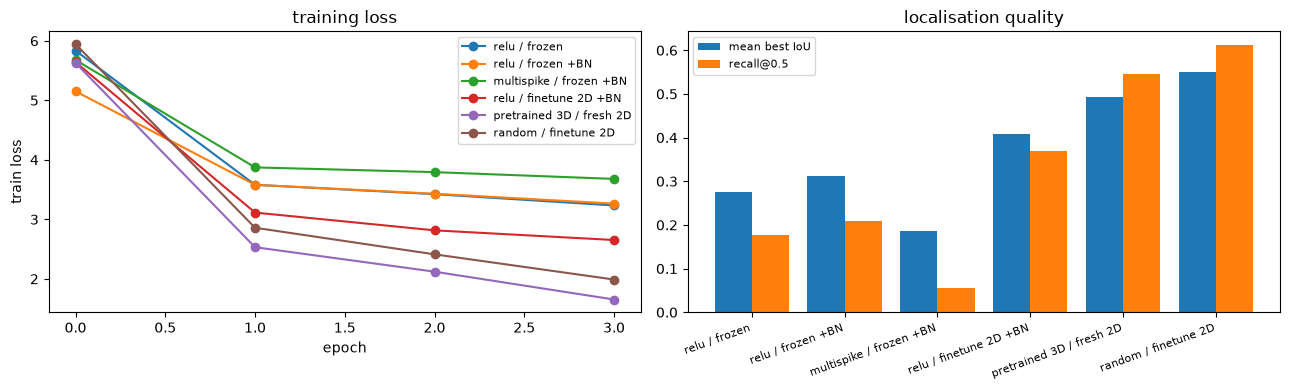

In [15]:
cols = ["mean_iou", "recall@0.25", "recall@0.5", "recall@0.75", "cls_acc@0.5", "top1_iou"]
print(f"{'run':26s}" + "".join(f"{c:>13s}" for c in cols))
print("-" * (26 + 13 * len(cols)))
for name, m in results.items():
    print(f"{name:26s}" + "".join(f"{m[c]:13.3f}" for c in cols))
print(f"\nevaluated on {next(iter(results.values()))['n_gt']} ground-truth boxes "
      f"in {len(test_ds)} test frames")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, m in results.items():
    ax[0].plot(m["history"], marker="o", label=name)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train loss"); ax[0].legend(fontsize=8)
ax[0].set_title("training loss")
x = np.arange(len(results))
ax[1].bar(x - 0.2, [m["mean_iou"] for m in results.values()], 0.4, label="mean best IoU")
ax[1].bar(x + 0.2, [m["recall@0.5"] for m in results.values()], 0.4, label="recall@0.5")
ax[1].set_xticks(x); ax[1].set_xticklabels(list(results), rotation=20, ha="right", fontsize=8)
ax[1].legend(fontsize=8); ax[1].set_title("localisation quality")
plt.tight_layout(); plt.show()

## 9. Predicting boxes

The best run, applied to test frames it never saw.

showing: random / finetune 2D


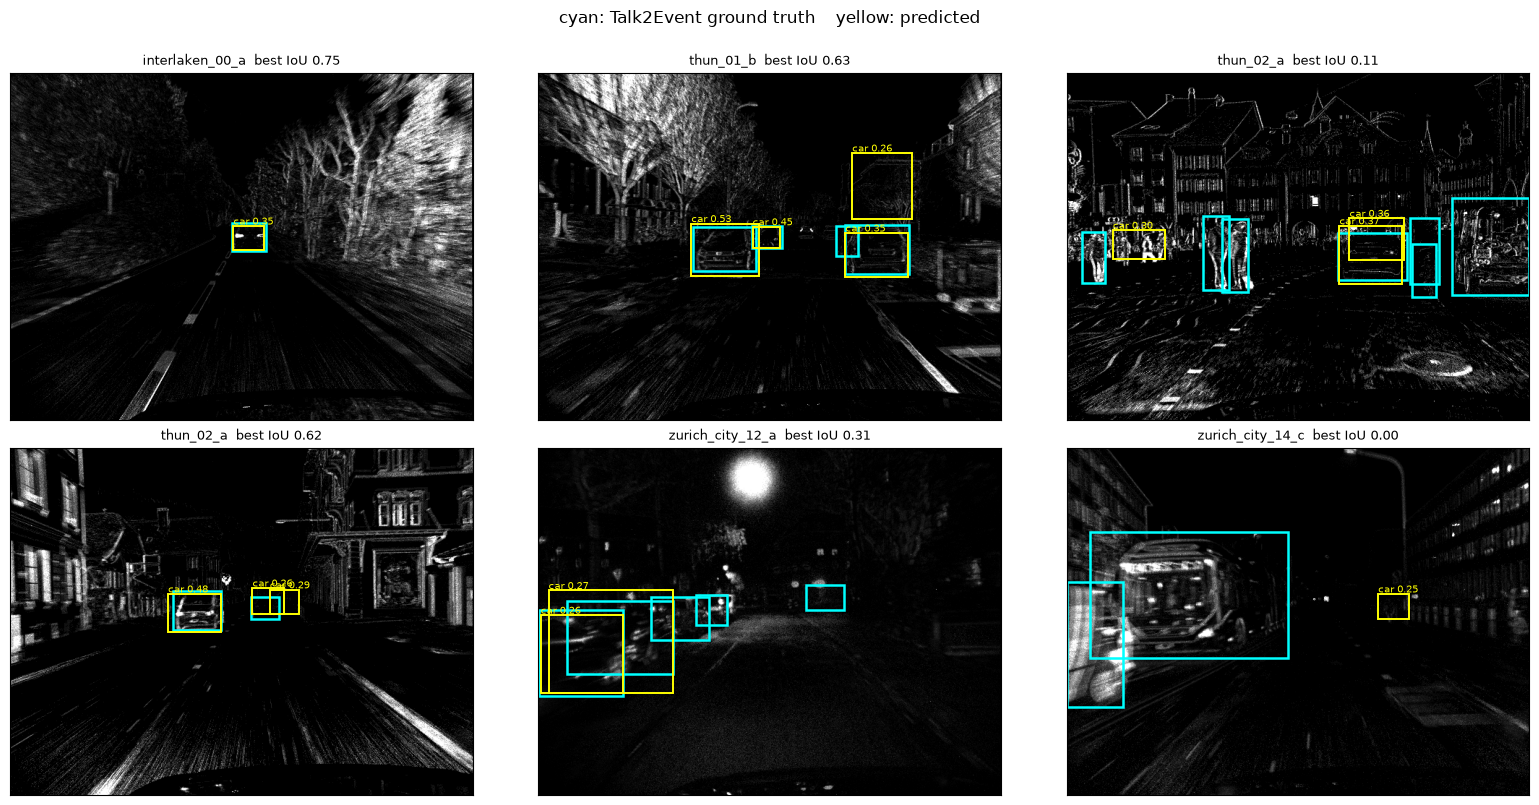

In [16]:
best_name = max(results, key=lambda k: results[k]["mean_iou"])
enc, head, ft = trained[best_name]
print(f"showing: {best_name}")


@torch.no_grad()
def predict_boxes(enc, head, event_volume, score_thresh=0.25, topk=20):
    """(20, H, W) event counts -> (N, 6) boxes [x0, y0, x1, y1, score, class]."""
    enc.eval(); head.eval()
    feats, coords = events_to_spike_voxels(event_volume[None])
    sp = sparse_features(enc, feats.to(DEVICE), coords.to(DEVICE), 1)
    bev = enc.backbone_2d({"spatial_features": sp})["spatial_features_2d"]
    pred = decode(*head(bev), k=topk)[0]
    return pred[pred[:, 4] >= score_thresh].cpu()


shown = test_index[:: max(1, len(test_index) // 6)][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (path, gt) in zip(axes.ravel(), shown):
    ev = torch.from_numpy(np.load(DATA / path)["events"].astype(np.float32))
    pred = predict_boxes(enc, head, ev)
    img = ev.view(2, T_FILE, EVENT_H, EVENT_W).sum((0, 1))
    ax.imshow(img, cmap="gray", vmax=np.percentile(img, 99.5))
    for x0, y0, x1, y1, c in gt:
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="cyan", lw=1.8))
    for x0, y0, x1, y1, s, c in pred.tolist():
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec="yellow", lw=1.4))
        ax.text(x0, y0 - 2, f"{CLASSES[int(c)]} {s:.2f}", color="yellow", fontsize=7)
    ious = iou_matrix(torch.tensor(gt, dtype=torch.float32)[:, :4], pred[:, :4]) \
        if len(pred) else torch.zeros(len(gt), 1)
    ax.set_title(f"{Path(path).parts[-3]}  best IoU {ious.max(1).values.mean():.2f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("cyan: Talk2Event ground truth    yellow: predicted", y=1.0)
plt.tight_layout(); plt.show()

## 10. Findings

**1. The released checkpoint is an ANN, and it is not a good event encoder.**
`kitti.pth` loads exactly (72/72 and 84/84 tensors) into OpenPCDet's classic
`VoxelBackBone8x` + `BaseBEVBackbone`, not into E-3DSNN's spike-first classes, so it is
the ANN VoxelRCNN-Car model. Anything that needs a *spiking* E-3DSNN has to be trained;
there are no released spiking detection weights.

**2. Making it spiking is the single most expensive change.** Same weights, ReLU ->
`Multispike`: the stride-8 feature map goes from **19% to 0.6% nonzero** and box quality
from **0.312 to 0.185** mean IoU (recall@0.5 0.210 -> 0.055). The activations these
convs were trained to produce do not survive quantisation to {0,1,2,3,4}.

**3. The transfer is negative, and both halves of the checkpoint contribute.** Reading
the table bottom-up isolates it:

| what is pretrained | mean IoU | recall@0.5 |
|---|---|---|
| 3D + 2D trunk (fine-tuned) | 0.409 | 0.369 |
| 3D only, 2D trunk from scratch | 0.493 | 0.547 |
| nothing (random, frozen 3D) | **0.549** | **0.613** |

Discarding the pretrained 2D trunk gains +0.084 IoU; discarding the pretrained sparse-3D
weights on top of that gains a further +0.056. A **frozen randomly-initialised** sparse
3D encoder beats the KITTI-pretrained one. Both differences reproduced across two full
runs (within 0.01), on all 1134 test frames / 3127 boxes.

Why this is the expected outcome rather than a bug: the checkpoint's first conv consumes
`MeanVFE` features -- mean point coordinates in *metres* over the KITTI range -- which
for events can only be fabricated from pixel and time indices, and its learned 3D
structure assumes the third axis is height where ours is time. Recalibrating BatchNorm
on event data recovers part of the gap (0.274 -> 0.312) and costs nothing, but does not
change the conclusion.

**4. What does work is the pipeline.** Events go into sparse convolutions with no
preprocessing (534k active sites, 17% occupancy, 46-60 ms and ~1 GiB per frame), the
stride-8 map lands on the image plane, and a CenterNet head on top reaches
**IoU 0.549 / recall@0.5 0.613 / recall@0.25 0.868** after 4 epochs at ~47 s/epoch over
all 4433 train frames -- with the sparse half frozen under `no_grad`, so the whole thing
costs one sparse forward per frame per epoch.

### Limits of these numbers

* **recall@0.75 is 0.245.** A single stride-8 map is coarse for a 64x51 px median object;
  the offset branch fixes the centre but not the size resolution.
* **Class accuracy at IoU>=0.5 is 0.435** -- localisation is much better than
  recognition here, which is what one would expect from a 4-epoch head.
* **`top1_iou` (0.191) is not a grounding score.** It takes the single
  highest-scoring box with no caption to select *which* object was meant; frames average
  2.76 annotated objects. Language conditioning is exactly what this notebook leaves out.

### Next steps for spiketrandvg

1. **Tap multiple scales.** `x_conv2`/`x_conv3` (strides 2 and 4) are already returned by
   the encoder; an FPN over them is the direct fix for recall@0.75.
2. **Train the sparse-3D half** rather than transferring it -- given result 3, E-3DSNN's
   architecture is worth keeping and its KITTI weights are not.
3. **Keep polarity.** These runs used `feature_mode="kitti_like"`, which spends a channel
   on a fabricated metric coordinate and drops the polarity signal; `"event_counts"`
   keeps it and is the right input once the encoder is trained rather than transferred.
4. **Condition on the caption** to turn this detector into the grounding model, e.g. by
   fusing the text encoder's tokens with the stride-8 map before the head.
